In [1]:
"""This notebook investigates the structure and contents of the MANTRA astronomical transient dataset before preprocessing or feature engineering. Each source file is analyzed independently to understand its observations, variables, labels, and relationships."""

'This notebook investigates the structure and contents of the MANTRA astronomical transient dataset before preprocessing or feature engineering. Each source file is analyzed independently to understand its observations, variables, labels, and relationships.'

In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.untiles import statistics

In [3]:
light_curve=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\transient_lightcurves.csv')
labels=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\transient_labels.csv')
info=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\transient_info.txt',sep='\t')

In [4]:
light_curve.head()

,ID,observation_id,Mag,Magerr,MJD
0,TranID1409030010044114444,0,18.8765,0.166417,53766.089871
1,TranID1409030010044114444,1,20.0519,0.281733,53990.458866
2,TranID1409030010044114444,2,20.2199,0.295764,53996.286004
3,TranID1409030010044114444,3,21.1192,0.495390,54385.205789
4,TranID1409030010044114444,4,19.3289,0.195002,54355.282285


In [5]:
labels.head()

,Classification,TransientID
0,Flare,1611101400424116462
1,HPM,1611101210274176502
2,HPM,1611101150154137989
3,HPM,1611091630244128695
4,CV,1611091600294129774


In [6]:
info.head()

,#CRTS ID,RA (J2000),Dec (J2000),UT Date,Mag,CSS images,SDSS,Others,Followed,Last,LC,FC,Classification
0,CSS120828:000010-215515,0.04323,-21.92087,20120828.38,17.02,1208280210014111715,no,11171,no,2016-10-22,11171,yes,Var
1,CSS100910:000025+332543,0.10280,33.42861,20100910.42,15.85,1009101320014148188,yes,14818,no,2016-11-05,14818,yes,"CV SDSS mag 20,5"
2,CSS101127:000130+050624,0.37695,5.10657,20101127.21,15.68,1011271040014129121,no,12912,yes,2016-11-06,12912,yes,"CV mag 20,0"
3,CSS160709:000132+211336,0.38474,21.22680,20160709.45,17.21,1607091210014124380,yes,12438,no,2016-11-05,12438,yes,Blazar CRATES_J0001+2113
4,CSS110926:000156+065236,0.48205,6.87665,20110926.30,19.35,1109261070014122864,no,12286,yes,2016-11-06,12286,yes,"SN 2011hl SDSS mag 15,7 2MASX_00015920"


In [7]:
light_curve.info()

<class 'pandas.DataFrame'>
RangeIndex: 440469 entries, 0 to 440468
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID              440469 non-null  str    
 1   observation_id  440469 non-null  int64  
 2   Mag             440469 non-null  float64
 3   Magerr          440469 non-null  float64
 4   MJD             440469 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 16.8 MB


In [8]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 5539 entries, 0 to 5538
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Classification  5539 non-null   str  
 1   TransientID     5539 non-null   int64
dtypes: int64(1), str(1)
memory usage: 86.7 KB


In [9]:
info.info()

<class 'pandas.DataFrame'>
RangeIndex: 5539 entries, 0 to 5538
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   #CRTS ID        5539 non-null   str    
 1   RA (J2000)      5539 non-null   float64
 2   Dec (J2000)     5539 non-null   float64
 3   UT Date         5539 non-null   float64
 4   Mag             5539 non-null   float64
 5   CSS images      5539 non-null   int64  
 6   SDSS            5539 non-null   str    
 7   Others          5539 non-null   int64  
 8   Followed        5539 non-null   str    
 9   Last            5539 non-null   str    
 10  LC              5539 non-null   int64  
 11  FC              5539 non-null   str    
 12  Classification  5539 non-null   str    
dtypes: float64(4), int64(3), str(6)
memory usage: 562.7 KB


In [10]:
info.describe(include='all')

,#CRTS ID,RA (J2000),Dec (J2000),UT Date,Mag,CSS images,SDSS,Others,Followed,Last,LC,FC,Classification
count,5539,5539.000000,5539.000000,5.539000e+03,5539.000000,5.539000e+03,5539,5539.000000,5539,5539,5539.000000,5539,5539
unique,5539,NaN,NaN,NaN,NaN,NaN,2,NaN,2,118,NaN,2,2948
top,CSS120828:000010-215515,NaN,NaN,NaN,NaN,NaN,yes,NaN,no,2016-11-06,NaN,yes,SN SDSS mag >22
freq,1,NaN,NaN,NaN,NaN,NaN,4082,NaN,3774,458,NaN,4723,80
mean,NaN,164.835705,15.440792,2.012067e+07,17.810554,1.206664e+18,NaN,14998.998195,NaN,NaN,14998.998195,NaN,NaN
std,NaN,95.348778,20.030856,2.483236e+04,1.875867,2.483236e+17,NaN,8687.327097,NaN,NaN,8687.327097,NaN,NaN
min,NaN,0.043230,-30.865480,2.007032e+07,12.010000,7.032011e+17,NaN,1062.000000,NaN,NaN,1062.000000,NaN,NaN
25%,NaN,78.375790,-0.278370,2.010057e+07,16.910000,1.005661e+18,NaN,11231.000000,NaN,NaN,11231.000000,NaN,NaN
50%,NaN,172.090570,15.541760,2.012062e+07,18.350000,1.206181e+18,NaN,12578.000000,NaN,NaN,12578.000000,NaN,NaN
75%,NaN,224.128455,30.375035,2.014061e+07,19.190000,1.406081e+18,NaN,14246.000000,NaN,NaN,14246.000000,NaN,NaN


In [11]:
light_curve.describe(include='all')

,ID,observation_id,Mag,Magerr,MJD
count,440469,440469.000000,440469.000000,440469.000000,440469.000000
unique,4869,NaN,NaN,NaN,NaN
top,TranID1502081400484121702,NaN,NaN,NaN,NaN
freq,564,NaN,NaN,NaN,NaN
mean,NaN,222407.913690,18.608208,0.192196,55192.221880
std,NaN,129095.392172,1.705348,0.105563,896.659266
min,NaN,0.000000,10.161000,0.049932,53464.153988
25%,NaN,110758.000000,18.019800,0.116256,54454.437468
50%,NaN,221678.000000,18.990700,0.172865,55246.188890
75%,NaN,333131.000000,19.716500,0.244321,56000.372478


In [12]:
labels.describe(include='all')

,Classification,TransientID
count,5539,5.539000e+03
unique,106,NaN
top,SN,NaN
freq,1723,NaN
mean,NaN,1.206664e+18
std,NaN,2.483236e+17
min,NaN,7.032011e+17
25%,NaN,1.005661e+18
50%,NaN,1.206181e+18
75%,NaN,1.406081e+18


(0.0, 2500.0)

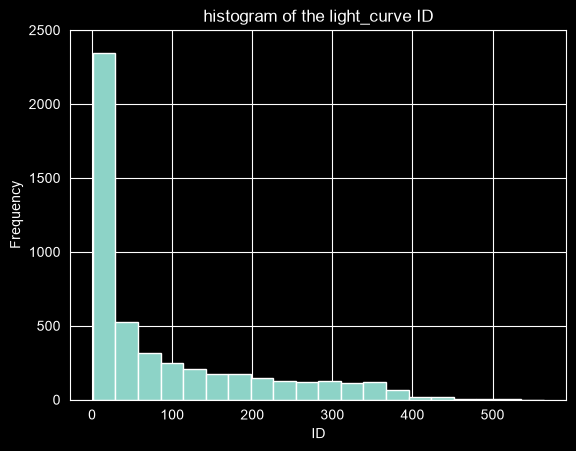

In [13]:
ax=light_curve['ID'].value_counts().plot(kind='hist',bins=20)
plt.xlabel('ID')
plt.title('histogram of the light_curve ID')
plt.ylim(0,2500)

In [14]:
statistics(light_curve['ID'].value_counts())

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,90.463956,34.0,111.507299,564,1,9.0,34.0,142.0


Text(0.5, 0, 'mag')

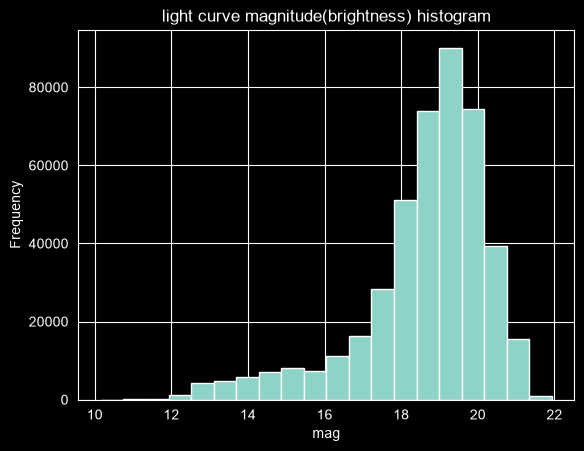

In [15]:
light_curve.Mag.plot(kind='hist',bins=20)
plt.title('light curve magnitude(brightness) histogram')
plt.xlabel('mag')

In [16]:
statistics(light_curve.Mag)

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,18.608208,18.9907,1.705346,21.9328,10.161,18.0198,18.9907,19.7165


Text(0.5, 1.0, 'the light curve uncertainty in the brightness measurement histogram and kde graph')

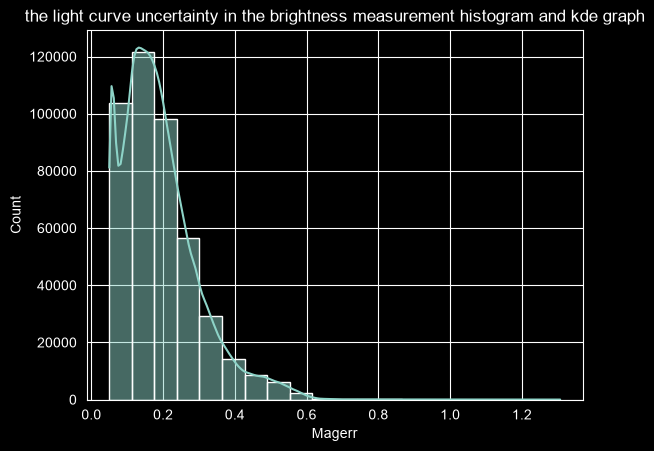

In [17]:
ax=sns.histplot(light_curve.Magerr,kde=True,bins=20)
ax.set_title('the light curve uncertainty in the brightness measurement histogram and kde graph')

In [18]:
statistics(light_curve['Magerr'])

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,0.192196,0.172865,0.105563,1.30665,0.049932,0.116256,0.172865,0.244321


Text(0.5, 1.0, 'light curve observation MJD histogram graph')

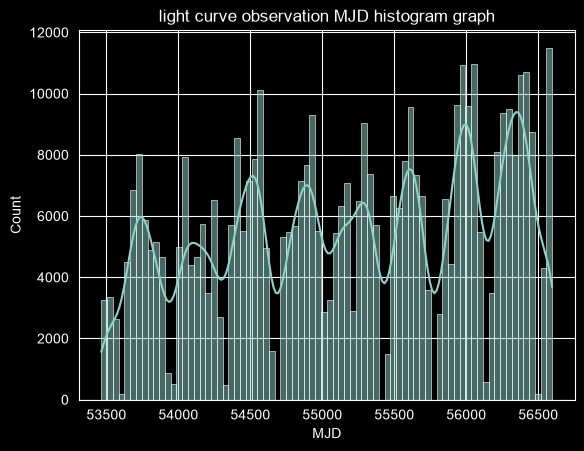

In [19]:
ax=sns.histplot(light_curve.MJD,kde=True)
ax.set_title("light curve observation MJD histogram graph")

In [20]:
statistics(light_curve.MJD)

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,55192.22188,55246.18889,896.658248,56596.514048,53464.153988,54454.437468,55246.18889,56000.372478


<Axes: >

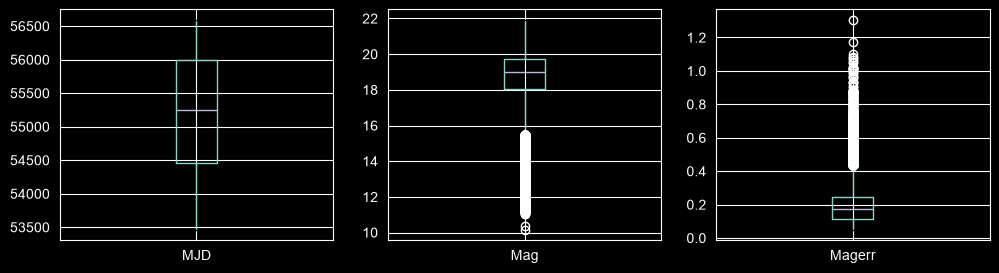

In [21]:
fig,ax=plt.subplots(1,3,figsize=(12,3))
light_curve.boxplot(column=['MJD'],ax=ax[0])
light_curve.boxplot(column=['Mag'],ax=ax[1])
light_curve.boxplot(column=['Magerr'],ax=ax[2])

In [22]:
labels.Classification.value_counts()

Classification
SN           1723
CV            988
HPM           640
AGN           446
SN?           319
             ... 
SN/TDE?         1
Ast/Var??       1
SN/Var?         1
Ast/SN?         1
Var/Nova        1
Name: count, Length: 106, dtype: int64

In [23]:
labels.Classification.nunique()

106

In [24]:
labels[labels.Classification.str.contains(f'SN')].Classification.nunique()

24

In [25]:
sn_containers=labels[labels.Classification.str.contains(f'SN')]
sn_containers.Classification.value_counts()

Classification
SN             1723
SN?             319
SN/CV            36
SN/AGN           23
CV/SN            19
SN/AGN?          11
SN/Ast           10
AGN/SN            6
SN/CV?            6
SN/TDE            6
AGN/SN?           4
Ast/SN            4
SN/Var            3
Flare/SN          2
Var/SN            2
SN/Ast?           2
Var/SN?           2
Flare/SN?         1
Blazar/SN         1
CV/SN?            1
SN/nothing?       1
SN/TDE?           1
SN/Var?           1
Ast/SN?           1
Name: count, dtype: int64

In [26]:
non_sn=labels[~labels.Classification.str.contains(f'SN')]
non_sn_clean=non_sn[~(non_sn.Classification.str.contains(r'\?')|non_sn.Classification.str.contains(r'/'))]
non_sn_clean.Classification.nunique()

33

In [27]:
non_sn_clean.value_counts()

Classification  TransientID        
Flare           1611101400424116462    1
HPM             1611101210274176502    1
                1611101150154137989    1
                1611091630244128695    1
CV              1611091600294129774    1
                                      ..
                711150010264146078     1
                711121350134134677     1
                711120010484141981     1
                711081290154130838     1
Flare           711020070134114830     1
Name: count, Length: 2938, dtype: int64

In [28]:
clean_label=labels[~(labels.Classification.str.contains(r'\?')|labels.Classification.str.contains(r'/')|labels.Classification.str.contains('Unknown'))]
clean_label.shape

(4433, 2)

In [29]:
clean_label.TransientID.nunique()

4433

In [30]:
transientID_labels=clean_label.TransientID.astype(str)

In [31]:
id_light_curve=pd.Series(light_curve.ID.unique()).str.replace('TranID',"",regex=False)
id_light_curve.shape

(4869,)

In [32]:
compare=id_light_curve.isin(transientID_labels)
compare.value_counts()

True     3861
False    1008
Name: count, dtype: int64

In [33]:
new_light_curve=light_curve[light_curve.ID.str.replace('TranID','',regex=False).isin(transientID_labels)]
new_light_curve.shape

(398635, 5)

In [34]:
statistics(new_light_curve.ID.value_counts())

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,103.246568,45.0,116.802677,564,1,12.0,45.0,171.0


In [35]:
statistics(new_light_curve.observation_id.value_counts())

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,1.0,1.0,0.0,1,1,1.0,1.0,1.0


In [36]:
statistics(info['#CRTS ID'].value_counts())

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,1.0,1.0,0.0,1,1,1.0,1.0,1.0


Text(0.5, 1.0, 'RA (j2000) histogram and kde graph')

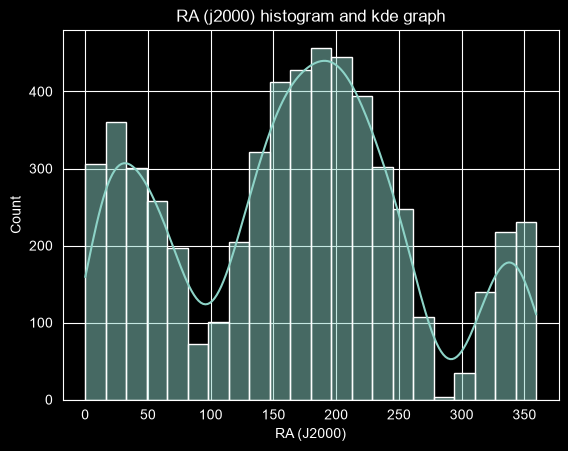

In [37]:
ax=sns.histplot(info['RA (J2000)'],kde=True)
ax.set_title('RA (j2000) histogram and kde graph')

In [38]:
statistics(info['RA (J2000)'])

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,164.835705,172.09057,95.34017,359.34494,0.04323,78.37579,172.09057,224.128455


Text(0.5, 1.0, 'Dec (j2000) histogram and kde graph')

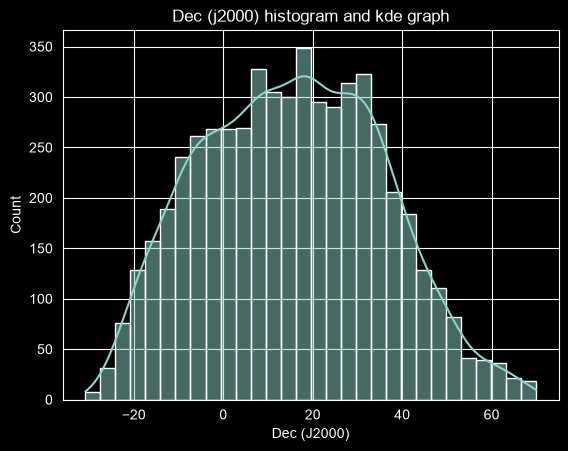

In [39]:
ax=sns.histplot(info['Dec (J2000)'],kde=True)
ax.set_title('Dec (j2000) histogram and kde graph')

In [40]:
statistics(info['Dec (J2000)'])

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,15.440792,15.54176,20.029047,69.94592,-30.86548,-0.27837,15.54176,30.375035


Text(0.5, 1.0, 'the brightness(Mag) distribution in info dataframe')

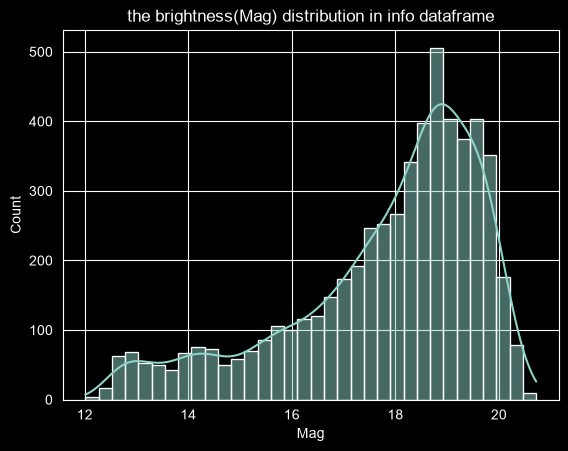

In [41]:
ax=sns.histplot(info.Mag,kde=True)
ax.set_title('the brightness(Mag) distribution in info dataframe')

In [42]:
statistics(info.Mag)

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,17.810554,18.35,1.875698,20.72,12.01,16.91,18.35,19.19


In [43]:
info.Classification.nunique()

2948

In [44]:
info.Classification.value_counts()

Classification
SN SDSS mag >22                  80
CV mag 21                        53
Unknown SDSS mag >22             37
CV mag 20,5                      36
Unknown                          33
                                 ..
CV? SDSS mag 22,1                 1
Blazar PMN_J2345-1555 z=0,621     1
HPM LHS_4010                      1
Blazar HB89_2345-167 z=0,60       1
Comet 9P                          1
Name: count, Length: 2948, dtype: int64

In [45]:
(info.Classification.value_counts())

Classification
SN SDSS mag >22                  80
CV mag 21                        53
Unknown SDSS mag >22             37
CV mag 20,5                      36
Unknown                          33
                                 ..
CV? SDSS mag 22,1                 1
Blazar PMN_J2345-1555 z=0,621     1
HPM LHS_4010                      1
Blazar HB89_2345-167 z=0,60       1
Comet 9P                          1
Name: count, Length: 2948, dtype: int64

In [46]:
info[info.Classification.str.contains('SN')].Classification.nunique()

1146

Text(0.5, 1.0, 'UT Date of the info dataframe')

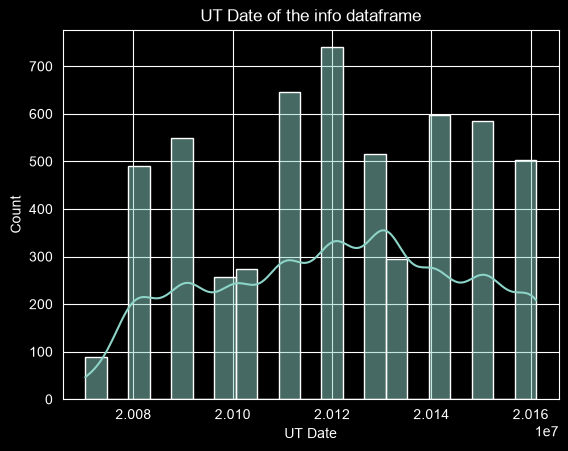

In [47]:
ax=sns.histplot(info['UT Date'],kde=True)
ax.set_title('UT Date of the info dataframe')

In [48]:
statistics(info['UT Date'])

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,2.012067e+07,20120618.27,24830.122718,20161110.5,20070320.37,2.010057e+07,20120618.27,2.014061e+07


In [49]:
info['LC'].nunique()

4040

In [50]:
info.LC.head(10)

0    11171
1    14818
2    12912
3    12438
4    12286
5    12787
6    10229
7    10325
8    12717
9    12407
Name: LC, dtype: int64

In [51]:
statistics(info['LC'])

,mean,median,std,max,min,quartile 1,quartile 2,quartile 3
0,14998.998195,12578.0,8686.542865,93480,1062,11231.0,12578.0,14246.0


In [52]:
match=info['LC']==info['Others']
match.value_counts()

True    5539
Name: count, dtype: int64

In [53]:
info['CSS images'].nunique()

5539

In [54]:
css=info['CSS images'].astype(str)
compare2=css.isin(transientID_labels)
compare2.value_counts()

CSS images
True     4433
False    1106
Name: count, dtype: int64

In [55]:
light_curve_ID=(pd.Series(new_light_curve.ID.unique()).str.replace('TranID',"",regex=False).astype(int))
structured_labels=clean_label[clean_label.TransientID.isin(light_curve_ID)]
structured_labels.shape

(3861, 2)

In [56]:
structured_info=info[info['CSS images'].isin(light_curve_ID)]
structured_info.shape

(3861, 13)

In [57]:
structured_info.to_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\structured_info.csv',index=False)
structured_labels.to_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\structured_labels.csv',index=False)
new_light_curve.to_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\structured_light_curve.csv',index=False)

In [58]:
""""
# Notebook 01 — Data Understanding and Structuring

## Purpose
This notebook was used to inspect and understand the three original datasets before
performing EDA, joining the datasets, or engineering features.

## Original datasets

### labels
- Contains 5,539 transient objects.
- Contains `TransientID` and `Classification`.
- `TransientID` uniquely identifies each transient.
- `Classification` contains the original human/catalog classifications.
- There are 106 unique classification values.

### light_curve
- Contains 440,469 individual observations.
- Contains 4,869 unique transient IDs.
- Each row represents an observation of a transient.
- `ID` identifies the transient and contains the `TranID` prefix.
- `observation_id` identifies the observation.
- `Mag` contains the measured magnitude.
- `Magerr` contains the magnitude measurement uncertainty.
- `MJD` represents the observation time.

### info
- Contains 5,539 transient objects and 13 columns.
- `#CRTS ID` is unique for every row.
- `RA (J2000)` and `Dec (J2000)` describe the object's sky position.
- `Mag` contains catalog-level magnitude information.
- `UT Date` contains the observation date in an encoded numerical format.
- `Classification` contains detailed catalog annotations rather than standardized
  classification categories.
- `CSS images` is unique for every row.
- `LC` and `Others` contain exactly the same values and therefore represent
  duplicate information.

## Label cleaning

The original classifications were inspected to determine which objects could be
used reliably for the supervised-learning task.

Classifications containing:
- `?`
- `/`
- `Unknown`

were removed because they represent uncertain, ambiguous, or unclear classifications.

This produced:

- 4,433 cleanly classified transients.

## Dataset relationships

The following identifier relationships were established:

`labels.TransientID`
↕
`light_curve.ID` after removing the `TranID` prefix

`labels.TransientID`
↕
`info.CSS images`

The clean labels were then restricted to transients that have corresponding
light-curve observations.

Final structured population:

- 3,861 transients with clean labels and light-curve data.
- 398,635 individual light-curve observations.

The corresponding information was extracted into three structured DataFrames:

- `structured_labels`
- `structured_info`
- `new_light_curve`

## Saved datasets

The structured datasets were saved as:

- `structured_labels.csv`
- `structured_info.csv`
- `structured_light_curve.csv`

These files will be used as the starting point for the next stage of the project:
Exploratory Data Analysis (EDA).

No feature engineering or modeling was performed in this notebook.
"""

'"\n# Notebook 01 — Data Understanding and Structuring\n\n## Purpose\nThis notebook was used to inspect and understand the three original datasets before\nperforming EDA, joining the datasets, or engineering features.\n\n## Original datasets\n\n### labels\n- Contains 5,539 transient objects.\n- Contains `TransientID` and `Classification`.\n- `TransientID` uniquely identifies each transient.\n- `Classification` contains the original human/catalog classifications.\n- There are 106 unique classification values.\n\n### light_curve\n- Contains 440,469 individual observations.\n- Contains 4,869 unique transient IDs.\n- Each row represents an observation of a transient.\n- `ID` identifies the transient and contains the `TranID` prefix.\n- `observation_id` identifies the observation.\n- `Mag` contains the measured magnitude.\n- `Magerr` contains the magnitude measurement uncertainty.\n- `MJD` represents the observation time.\n\n### info\n- Contains 5,539 transient objects and 13 columns.\n- `#